# Proyecto I – Parte IV (Core)

Análisis y Predicción de Ventas en una Tienda de Retail

## **Seccion 1:** Presentación del Problema.

En esta cuarta parte del proyecto, aplicaremos técnicas avanzadas de análisis exploratorio de datos (EDA) y visualización para comprender mejor el conjunto de datos de ventas de la tienda de retail. Utilizaremos Python, Pandas y Matplotlib para explorar y visualizar los datos, identificar patrones y tendencias, y preparar los datos para un análisis más profundo.


- Instrucciones

1. Continuar desde la Parte III
    + Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.

2. Análisis Descriptivo y Visualización
    + Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
    + Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
    + Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
    + Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
    + Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

3. Generar un Pull Request en GitHub
    + Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.



## **Sección 2:** Resolución del Problema.

### **Paso 1**  Cargar los Datos y librerias

- Importación  de las principales librerías que se podrían utilizar en el estudio.
- Carga del Dataframe

In [184]:
#Carga del dataframe
import pandas as pd
import numpy as np
df=pd.read_csv(r'..\data\retail_sales_dataset.csv')

print(f'Dataset cargado exitosamente!')
print(f'='*50)
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'='*50)
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'='*50)
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 1000 filas x 9 columnas
Memoria aproximada: 260 KB

Columnas: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


### **Paso 2** Exploración inicial de datos.

-   Se realiza la exploración de datos, con la finalidad de revisar como quedo el nuevo DataFrame limpio.
-    El comando df.head(10), que permite mostrar las primeras 10 filas. Se observa que no existen datos erroneos al inicio.
-   Mediante el comando df.tail(5), mostramos las últimas 5 filas. Se observa que no existen datos erroneos al final.
-   Mediante el comando df.info(), mostramos la informacinón general del DataFrame entre ellas:
    -   número de entradas: 1000  entradas.
    -   nombres de columnas: 9 columnas desde 'Transaction ID' hasta 'Total Amount'
    -   tipo de datos: 5 columnas son int y 4 columnas str.
    -   memoria utilizada: 70.4 KB
    -   No existe data con problemas.
-   Además, se muestras datos estadísticos asociado a datos numéricos.
- Por último, se confirma que el repositorio de GitHub está clonado localmente.

In [185]:
#Carga del dataframe
import pandas as pd
import numpy as np
df=pd.read_csv(r'..\data\retail_sales_dataset.csv')
#df

#Se muestran filas y columnas
print("Se presentan filas y columnas")
print("="*80)
print(df.shape)
print("-"*80)

#Se muestran las primeras 10 filas del DataFrame
print("Se presentan las primeras 10 filas")
print("="*80)
print(df.head(10))
print("-"*80)

#Se muestran las últimas 5 filas del DataFrame
print("Se presenta las últimas 5 filas")
print("="*80)
print(df.tail(5))
print("-"*80)

#Información general del DataFrame
print("Se presenta información general del DataFrame")
print("="*80)
print(df.info())
print("-"*80)

#Estadísticas descriptivas de columnas numéricas y de categoría
print("Se presentan estadísticas descriptivas del DataFrame")
print('='*40+'Columnas numericas'*1+'='*40)
display(df.describe())
print(" "*80)
print('='*40+'Columnas categoricas'*1+'='*40)
display(df.describe(include='str'))

Se presentan filas y columnas
(1000, 9)
--------------------------------------------------------------------------------
Se presentan las primeras 10 filas
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


                                                                                
========================================Columnas categoricas========================================


,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST001,Female,Clothing
freq,11,1,510,351


### **Paso 3** Limpieza de Datos.

3.1 Verificar y corregir tipos de datos


In [186]:
print('Tipos antes de limpiar:')
display(df.dtypes)
print()

#Revisión de Variables
#print('Valores unicos en Transaction ID:', df['Transaction ID'].unique())
print('Valores unicos en Date:', df['Date'].unique())
#print('Valores unicos en Customer ID:', df['Customer ID'].unique())
print('Valores unicos en Gender:', df['Gender'].unique())
#print('Valores unicos en Age:', df['Age'].unique())
print('Valores unicos en Product Category:', df['Product Category'].unique())
print('Valores unicos en Quantity:', df['Quantity'].unique())
print('Valores unicos en Price per Unit:', df['Price per Unit'].unique())
#print('Valores unicos en Total Amount:', df['Total Amount'].unique())

# No hay datos sucios


print()


Tipos antes de limpiar:


Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


Valores unicos en Date: <StringArray>
['2023-11-24', '2023-02-27', '2023-01-13', '2023-05-21', '2023-05-06',
 '2023-04-25', '2023-03-13', '2023-02-22', '2023-12-13', '2023-10-07',
 ...
 '2023-09-26', '2023-07-04', '2023-05-30', '2023-10-21', '2023-09-03',
 '2023-03-02', '2023-08-02', '2023-04-17', '2023-03-30', '2023-05-28']
Length: 345, dtype: str
Valores unicos en Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Valores unicos en Product Category: <StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str
Valores unicos en Quantity: [3 2 1 4]
Valores unicos en Price per Unit: [ 50 500  30  25 300]



#### 3.2 Identificación de datos duplicados.

In [187]:
#Revisión de duplicados y de variable relevante (App) (Ayuda Jesus)

n_total = len(df)
n_dupes = df.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')
print()


Filas totales:           1000
Duplicados exactos:      0 (0.0%)



#### 3.3 Identificación de datos nulos

In [188]:
# Codigo para revisar nulos (Codigo aportado por Jesús)

null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral


#### 3.4 dentificar y eliminar outliers

- Se revisan datos atípicos de las variables relevantes-

- Nos eeliminan datos por se relvantes para la variables App.

In [189]:
#Codigo facilitado por Jesus para la revisón de datos atípicos

print('=== ANALISIS DE OUTLIERS ===')
print()

# --- Total Amount: usamos IQR para detectar extremos ---
q1, q3 = df['Total Amount'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_reviews = q3 + 1.5 * iqr
outliers_reviews = df[df['Total Amount'] > lim_reviews]
print(f'\nTotal Amount:')
print(f'  Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}  Limite IQR={lim_reviews:.0f}')
print(f'  Ventas con Reviews > limite IQR: {len(outliers_reviews)} ({len(outliers_reviews)/len(df)*100:.1f}%)')

# Eliminar solo Ratings imposibles
#filas_antes = len(df)
#df = df[(df['Rating'] >= 1.0) & (df['Rating'] <= 5.0)].copy().reset_index(drop=True)
#print(f'\nFilas eliminadas por Rating invalido: {filas_antes - len(df)}')
#print(f'Dataset limpio final: {df.shape[0]} filas x {df.shape[1]} columnas')
#print(f'Nulos totales: {df.isnull().sum().sum()}')

=== ANALISIS DE OUTLIERS ===


Total Amount:
  Q1=60  Q3=900  IQR=840  Limite IQR=2160
  Ventas con Reviews > limite IQR: 0 (0.0%)


#### 3.5 Resumen Final de limpieza

- A continuación se presenta el resumen de la data limpia.

- También se muestras las estidicas descriptivas de las variables númericas.

+ Además un resumen de las variables de categoria Product Category y Gender.

In [190]:
# Resumen de principales variables posterior a la Limpieza.

display(df.info())

print('=== RESUMEN DEL DATASET LIMPIO ===')
display(df[['Age','Quantity','Price per Unit','Total Amount']].describe().round(2))
print()
print(f'Distribucion de Product Category:')
print(df['Product Category'].value_counts().to_string())
print(f'Distribucion de Gender:')
print(df['Gender'].value_counts().to_string())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


None

=== RESUMEN DEL DATASET LIMPIO ===


,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0



Distribucion de Product Category:
Product Category
Clothing       351
Electronics    342
Beauty         307
Distribucion de Gender:
Gender
Female    510
Male      490


b) Carga de librerias y vectores de datos.

A continuacion, se cargan las librerias necesarias para realizar los gráficos siguientes. Además, se construyen los vectores a graficas y sus colores correspondientes.

In [191]:
# Llamado de las librerioas 'seaborn' y 'matplotlib.gridspec', para una mejor visualización.
import seaborn as sns
import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates




### **Paso 4** Exploración de Datos:

#### 4.1 Analisis de visualizaciones exploratorias.

Las variables que se utilizarán en este análisis son:

- Product Category.
- Gender.
- Quantiy.
- Price per Unit
- Total Amount.


#### 4.2 Agrupación de variables y estadisticas descriptivas.

A continuación, se presentan las agrupaciones de variables a utilizar en los gráficos. Ademas se determinan estadisticas descriptivas básicas para ultizar en los gráficos.

In [192]:
# Grupos y datos estadisticos básicos para los gráficos que se crearán

Q1 = df.query('`Product Category` == "Electronics"')
Q2 = df.query('`Product Category` == "Beauty"')
Q3 = df.query('`Product Category` == "Clothing"')

y1 = df['Age']
y2 = df['Quantity']
y3 = df['Price per Unit']
y4 = df['Total Amount']

# Se listan los datos en una matriz a gráficar de 2x2.
data_list = [(y1, 'Age'), (y2, 'Quantity'), 
             (y3, 'Price per Unit'), (y4, 'Total Amount')]

# Colores
color_relleno=['skyblue','green','orange','red']

# Convertir la columna 'fecha' a formato datetime
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')

# 2. Ordenar por fecha (Ascendente - más antigua primero)
df_ordenado = df.sort_values(by='Date')

# Por Categoria
Q1 = df_ordenado.query('`Product Category` == "Electronics"')
Q2 = df_ordenado.query('`Product Category` == "Beauty"')
Q3 = df_ordenado.query('`Product Category` == "Clothing"')

#Agrupación por día
Q1_dia=Q1.groupby(['Date'])['Total Amount'].agg(Total_Amount='sum')
Q2_dia=Q2.groupby(['Date'])['Total Amount'].agg(Total_Amount='sum')
Q3_dia=Q3.groupby(['Date'])['Total Amount'].agg(Total_Amount='sum')

#Agrupación por mes
Q1_mes = Q1.groupby(Q1['Date'].dt.to_period('M'))['Total Amount'].agg(Total_Amount='sum')
Q2_mes = Q2.groupby(Q2['Date'].dt.to_period('M'))['Total Amount'].agg(Total_Amount='sum')
Q3_mes = Q3.groupby(Q3['Date'].dt.to_period('M'))['Total Amount'].agg(Total_Amount='sum')

Q1_mes.index = Q1_mes.index.to_timestamp()
Q2_mes.index = Q2_mes.index.to_timestamp()
Q3_mes.index = Q3_mes.index.to_timestamp()

#### 4.3 Creación de Histogramas y boxplots

a) histograma

- La mayor cantidad de ingresos por ventas se concentran entre en el rango de 0-250.
-  Los tres grupos de productos 'Electronics', 'Beauty' y 'Clothing' presentan un comportamiento similar de ingresos por ventas.

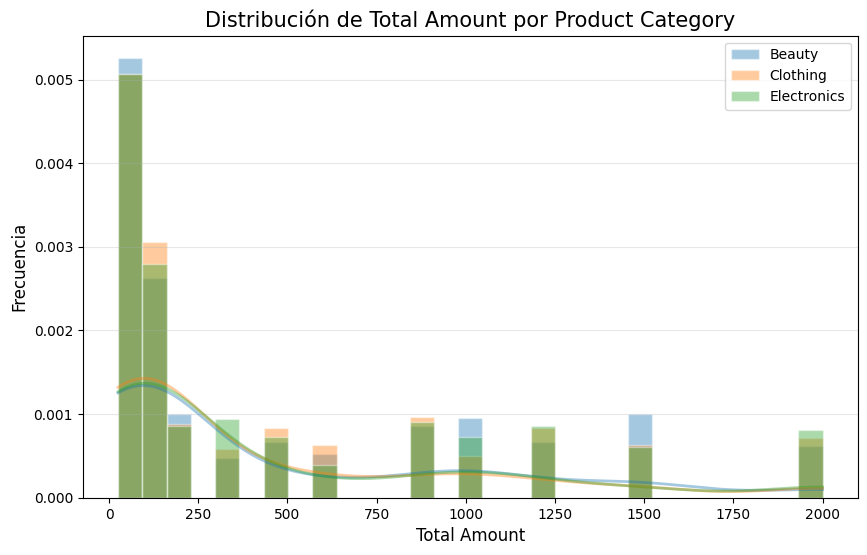

In [193]:
# Configuración de la figura  (Este código se mejoró con ayuda de google)
fig, ax = plt.subplots(figsize=(10, 6))

#Definición de bins comunes para los tres grupos para mejorar la comparación
bins = np.linspace(df['Total Amount'].min(), df['Total Amount'].max(), 30)

#Listas de grupos y colores
grupos = df['Product Category'].unique()
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde
alpha = 0.4

#Bucle para realizar los tres graficos en un histograma
for i, grupo in enumerate(grupos):
    #Filtrar datos del grupo actual
    datos_grupo = df[df['Product Category'] == grupo]['Total Amount']
    
    # Graficar histograma
    ax.hist(datos_grupo,
             bins=bins, 
             alpha=0.4,           # Transparencia
             label=grupo,         # Etiqueta para leyenda
             edgecolor='white',   # Borde claro para separar barras
             density=True,
             color=colores[i])    # Color único por grupo
    
    # Añadimos linea de densidad
    sns.kdeplot(datos_grupo, color=colores[i], ax=ax, linewidth=2,cut=0,alpha=.4)

#Personalización del gráfico
plt.title('Distribución de Total Amount por Product Category', fontsize=15)
plt.xlabel('Total Amount', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

b) Gráfico Boxplot

- Se observa que los rango intercuartiles tiene se instalan en las menores datos de ventas, lo cual reafirma lo indicado con los resultados del histograma.
- El grupo 'Clothing' presenta datos atípicos.

Text(0, 0.5, 'Total Amount')

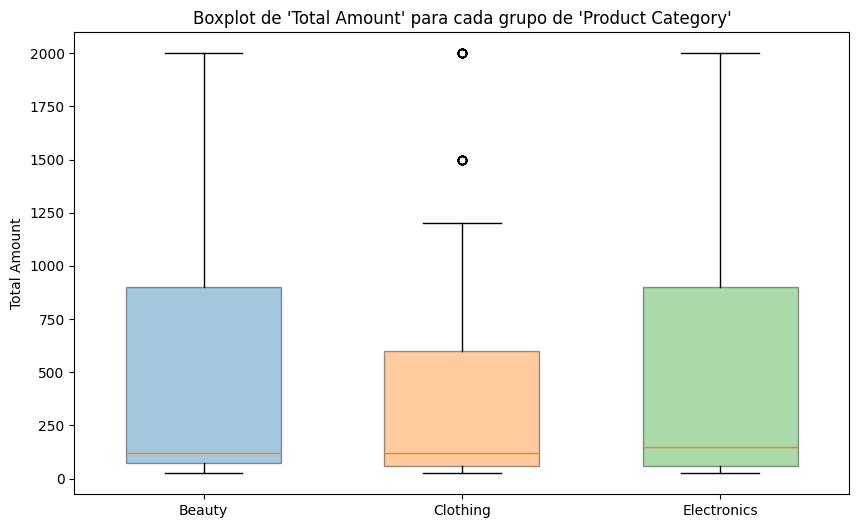

In [194]:
#Figura  (Este código se mejoró con ayuda de google)
fig, ax = plt.subplots(figsize=(10, 6))

# Bucle for para realizar los boxplots
for i, grupo in enumerate(grupos):
    #Filtrar datos por grupo
    datos_grupo = df[df['Product Category'] == grupo]['Total Amount']
    
    #Graficar cada boxplot
    box = ax.boxplot(datos_grupo, positions=[i], patch_artist=True, widths=0.6)
    
    #Aplicar color y transparencia a cada caja
    for box in box['boxes']:
        box.set_facecolor(colores[i])
        box.set_alpha(alpha) # Aplica transparencia al relleno
        box.set_edgecolor('black')   # Color del borde

# 4. Configurar etiquetas del eje X (solución al error de labels)
ax.set_xticks(range(len(grupos)))
ax.set_xticklabels(grupos)
ax.set_title("Boxplot de 'Total Amount' para cada grupo de 'Product Category'")
ax.set_ylabel("Total Amount")

#### 4.4 Creación de Gráfico de lineas

a) Gráfico de linea, comportamiento en el tiempo

- Se construen las gráficas de linea en el tiempo para la variable 'Total Amount', que es la variable más relvante. Lo anterior para los tres grupos de la variable 'Product Category'.
- Se construye inicialmente el gráfico de lineas para una linea de tiempo diaria. Si bien este gráfico muestra el comportamiento de las ventas diarias, no se puede realizar un análisis compartivo entre los productos.
- Para realizar una comparación delos grupos se construye una gráfica mensualizada para poder comparar de mejor forma. En esya gráfica si bien cada categoria tiene altos y bajos ingresos a medida que pasan los meses, en términos promedios, las tres categorias tienen ingresos entre 12min y 13min unidades monetarias.

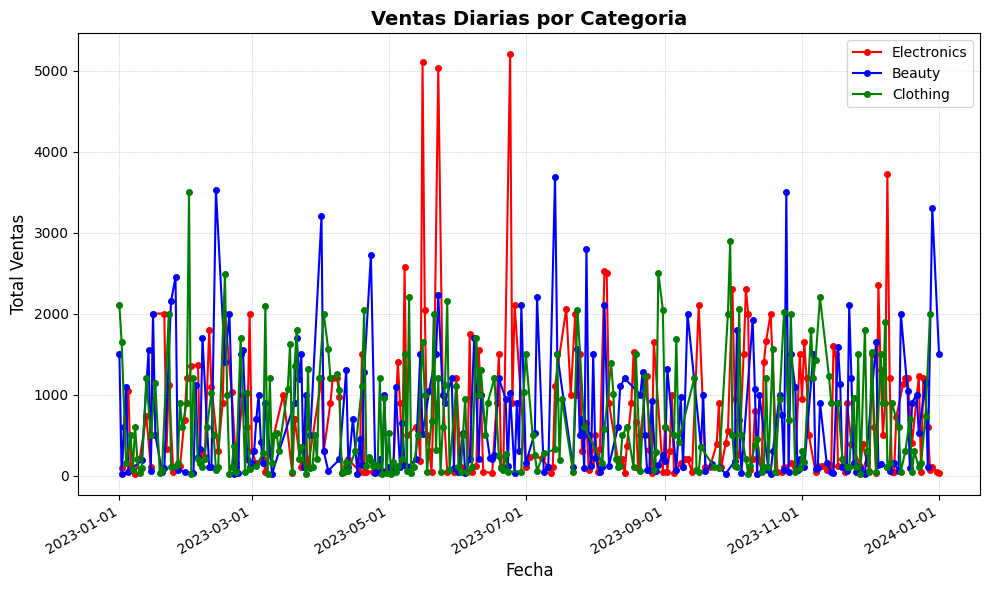

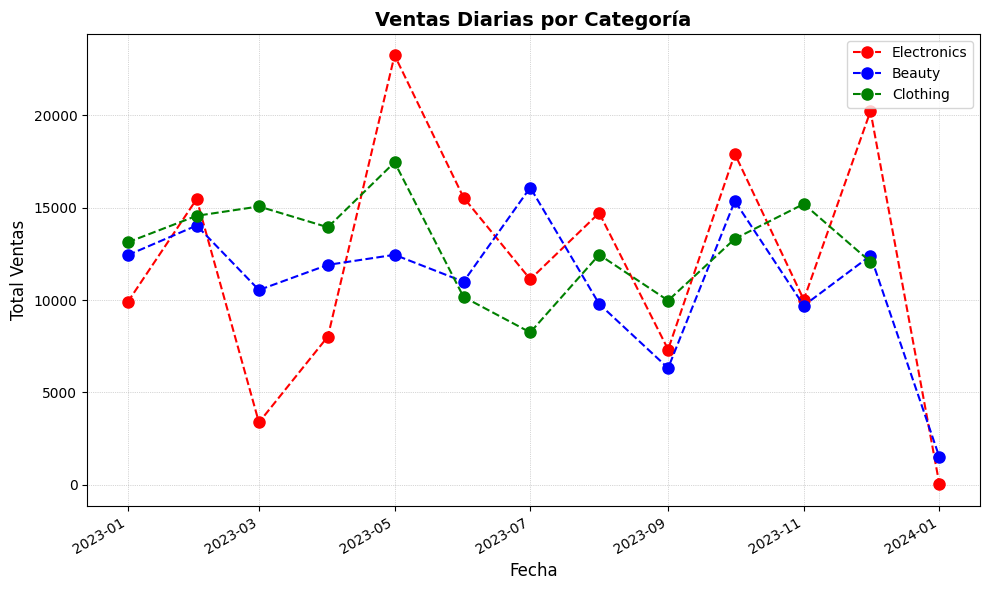

In [195]:
#Creación de gráficos de linea.  (Este código se mejoró con ayuda de google)

# Gráfico Diario
datos_a_graficar = [
    {'datos': Q1_dia, 'color': 'r', 'label': 'Electronics'},
    {'datos': Q2_dia, 'color': 'b', 'label': 'Beauty'},
    {'datos': Q3_dia, 'color': 'g', 'label': 'Clothing'}
]

fig, ax = plt.subplots(figsize=(10, 6))

# Bucle
for serie in datos_a_graficar:
    ax.plot(serie['datos'].index, 
            serie['datos'].values, 
            linestyle='-',
            color=serie['color'], 
            marker='o', 
            markersize=4,
            label=serie['label'], 
            linewidth=1.5)

# Formateo de fechas e intervalos
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()

# Ajustes para la presentación del gráfico
plt.title("Ventas Diarias por Categoria", fontsize=14, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Total Ventas", fontsize=12)
plt.tight_layout()
plt.legend() # Muestra las etiquetas (labels)
plt.grid(True, linestyle=':', linewidth=0.5)
plt.show()

# Gráfico Mensual
datos_a_graficar2 = [
    {'datos': Q1_mes, 'color': 'r', 'label': 'Electronics'},
    {'datos': Q2_mes, 'color': 'b', 'label': 'Beauty'},
    {'datos': Q3_mes, 'color': 'g', 'label': 'Clothing'}
]

fig, ax = plt.subplots(figsize=(10, 6))

# Bucle
for serie in datos_a_graficar2:
    ax.plot(serie['datos'].index, 
            serie['datos'].values, 
            linestyle='--', # Línea sólida para mejor visualización conjunta
            color=serie['color'], 
            marker='o', 
            markersize=8,
            label=serie['label'], 
            linewidth=1.5)

# Formateo de fechas e intervalos
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

# Ajustes para la presentación del gráfico
plt.title("Ventas Diarias por Categoría", fontsize=14, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Total Ventas", fontsize=12)
plt.tight_layout()
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.5)
plt.show()

#### 4.5 Creación de gráfico de dispersión

a) Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.

+ Para el gráfico de dispersión se seleccionan las variables de: 'Price per Unit' (Precio) y 'Total Amount' (Ingreso por ventas), para estudiar como afecta el precio al volumen vendido.
+ El comportamiento entre el precio y las ventas es similar para las tres categorias de productos.

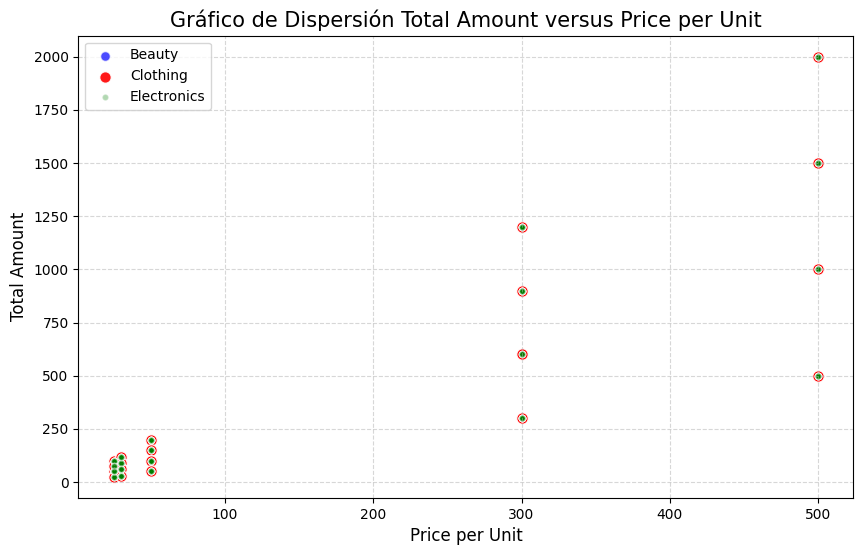

In [196]:
# Creación de gráficos de dispersión  (Este código se mejoró con ayuda de google)

# Por Categoria
lista_price = df.groupby('Product Category')['Price per Unit'].apply(list).reset_index()
lista_amount = df.groupby('Product Category')['Total Amount'].apply(list).reset_index()

# 2. Crear la figura
plt.figure(figsize=(10, 6))

# 3. Graficar cada grupo con un color y etiqueta diferente
plt.scatter(lista_price.iloc[0]['Price per Unit'],lista_amount.iloc[0]['Total Amount'], color='blue', label='Beauty', alpha=0.7, edgecolors='w', s=50)
plt.scatter(lista_price.iloc[1]['Price per Unit'],lista_amount.iloc[1]['Total Amount'], color='red', label='Clothing', alpha=0.9, edgecolors='w', s=70)
plt.scatter(lista_price.iloc[2]['Price per Unit'],lista_amount.iloc[2]['Total Amount'], color='green', label='Electronics', alpha=0.3, edgecolors='w', s=20)

# 4. Personalizar el gráfico
plt.title('Gráfico de Dispersión Total Amount versus Price per Unit', fontsize=15)
plt.xlabel('Price per Unit', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.legend() # Muestra la leyenda basada en los 'label'
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Mostrar el gráfico
plt.show()


#### 4.6 Creación de gráfico histograma y boxplot combinados.

e) Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.

- El gráfico de histogramas muestra que la distribución de ventras es similar para las tres categorías de productos.

- Por su parte el boxplot muestra que las tres categorías muestran una media muy simila, la categoría Electronics es levemente mayor.

- La categoría Cloting muestra un menor rango intercuartil que las otras categorías, con dos datos atípicos.

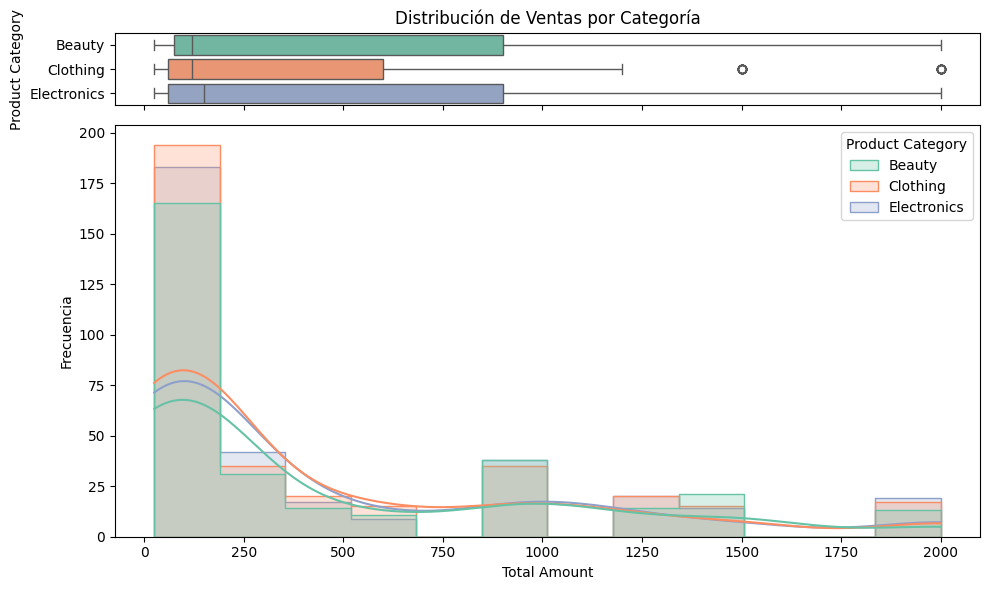

In [197]:
# Configuración figura con subplots compartidos (Este código se mejoró con ayuda de google)
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# Dibujar el Boxplot (arriba)
sns.boxplot(data=df, x="Total Amount", y="Product Category", hue="Product Category", ax=ax_box, palette="Set2")
ax_box.set(xlabel='') # Eliminar etiqueta x del boxplot
ax_box.set_title('Distribución de Ventas por Categoría')

# Dibujar el Histograma (abajo)
sns.histplot(data=df, x="Total Amount", hue="Product Category", element="step", ax=ax_hist, palette="Set2", kde=True)
ax_hist.set(ylabel='Frecuencia')


plt.tight_layout()
plt.show()